# Intermediate-Momentum -- does momentum live in the *intermediate* past?
### Novy-Marx (2012): the t-12..t-7 window vs the t-6..t-1 window, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Intermediate%20wins%3F: Busted](https://img.shields.io/badge/Intermediate%20wins%3F-Busted-8b949e?style=flat-square)

Cross-sectional momentum -- buy past winners, sell past losers -- usually ranks stocks on their return over the last twelve months (skipping the most recent one). In 2012, Robert Novy-Marx asked a sharp question: *which part* of that window does the work? He found the premium comes from the **intermediate** past -- roughly twelve to seven months ago -- and **not** the recent past (the months just before, which we implement as t-6..t-1). He called it momentum's 'echo'.

We test that decomposition on a large-cap survivor basket using yfinance daily prices: build one long-short ranked on the intermediate window, one on the recent window, and see which (if either) carries the drift.

> **This is the plain-language layer.** Want the formation windows, HAC *t*, the placebo and the cost ledger? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from intermediate_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "im_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "im_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    inter  = st.momentum_longshort(prices, window="intermediate", min_stocks=18)
    recent = st.momentum_longshort(prices, window="recent", min_stocks=18)
    s_int  = st.summary(inter["ls_ret"])
    s_rec  = st.summary(recent["ls_ret"])
    print(f"INT mean {s_int['mean']*100:+.2f}%/yr t={s_int['tstat']:+.3f} | "
          f"REC mean {s_rec['mean']*100:+.2f}%/yr t={s_rec['tstat']:+.3f}")


yfinance cache present: True


INT mean -0.31%/yr t=-0.121 | REC mean +0.25%/yr t=+0.090


## The answer first

| Question | Answer |
|---|---|
| Does the intermediate window carry a drift? | **No, not here.** Long-short **-0.31%/yr**, HAC *t* = **-0.12** -- inside its placebo distribution. |
| Does the recent window? | **Also no.** **+0.25%/yr**, *t* = **+0.09**. |
| Does intermediate beat recent (Novy-Marx's point)? | **No** -- the intermediate sort is, if anything, **marginally worse**. The echo is **Busted** on this basket. |
| Is it tradable? | **Mirage.** Both sorts go **negative net** of costs+borrow (-1.50% / -0.94%/yr). |

> Novy-Marx (2012) documented the intermediate effect on a broad CRSP cross-section. On 46 large-cap survivors it does not reproduce -- both windows are flat.

## 1 -- The claim

> *"Momentum is not really momentum. The return that predicts next month's cross-section is the return from twelve to seven months ago -- the intermediate horizon -- not the recent six months."*

-- Novy-Marx (2012), *Journal of Financial Economics*

Standard momentum ranks stocks on their past 12-month return (skipping month t-1, where short-term reversal lives). Novy-Marx split that window in two and showed the predictive power sat almost entirely in the older, intermediate slice. That is awkward for behavioural 'underreaction' stories, which would expect the *recent* news to drive the drift.

## 2 -- So what?

If true, the result reshapes how you build a momentum signal (rank on the intermediate window, ignore the recent one) and it constrains the theories that can explain momentum at all. It became one of the most-cited momentum refinements of the 2010s.

Our questions:
1. **Does either window carry a drift on a realistic large-cap panel?**
2. **Does the intermediate window beat the recent one, as claimed?**
3. **Does anything survive costs?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **One execution lag.** The signal is computed at month-end; we enter one trading day later. No look-ahead, no same-bar fills.
2. **A label-shuffle placebo.** We randomly permute which stocks are 'winners' vs 'losers' and re-run -- if the real labels carry no information, the real mean sits inside the shuffle distribution.
3. **Name the survivorship bias.** The basket is current large-caps projected backwards. Past losers that delisted -- the natural short leg -- are absent, so any premium here is an upper bound.

## 4 -- The teardown

**First, does the engine work when the effect is planted?** We build a synthetic world where a momentum premium exists *only* in the intermediate window.

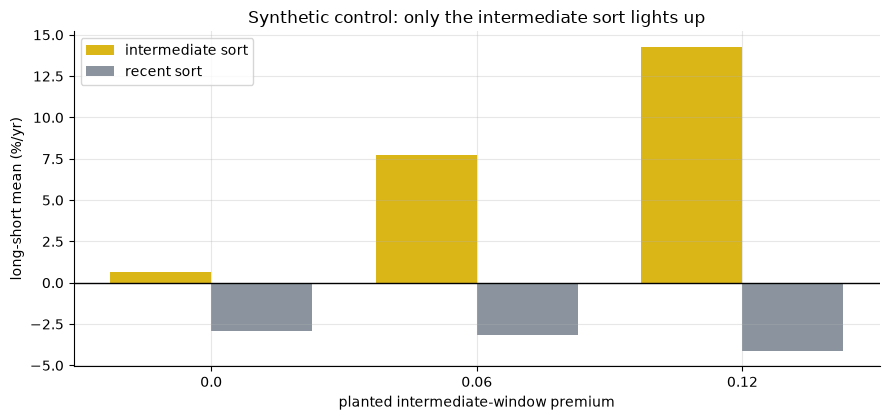

 premium  int_mean_%  int_t  rec_mean_%  rec_t
    0.00       0.661  0.266      -2.899 -1.300
    0.06       7.743  3.372      -3.148 -1.328
    0.12      14.291  6.259      -4.146 -1.776


In [2]:
premiums = [0.0, 0.06, 0.12]
rows = []
for prem in premiums:
    ps, sp, truth = data.synthetic_panel(mom_premium=prem, seed=509)
    ri = st.momentum_longshort(ps, window='intermediate', min_stocks=10)
    rr = st.momentum_longshort(ps, window='recent', min_stocks=10)
    si = st.summary(ri['ls_ret']); sr = st.summary(rr['ls_ret'])
    rows.append({'premium': prem,
                 'int_mean_%': si['mean']*100, 'int_t': si['tstat'],
                 'rec_mean_%': sr['mean']*100, 'rec_t': sr['tstat']})
ctrl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = np.arange(len(premiums)); w = 0.38
ax.bar(x - w/2, ctrl['int_mean_%'], w, color=AMBER, label='intermediate sort')
ax.bar(x + w/2, ctrl['rec_mean_%'], w, color=GREY, label='recent sort')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([str(p) for p in premiums])
ax.set_xlabel('planted intermediate-window premium')
ax.set_ylabel('long-short mean (%/yr)')
ax.set_title('Synthetic control: only the intermediate sort lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: it finds the planted drift in the **intermediate** sort (growing with the premium) and leaves the **recent** sort flat. So the verdict on the real tape reflects the market, not a broken detector.

**Now the honest test on the real yfinance panel.**

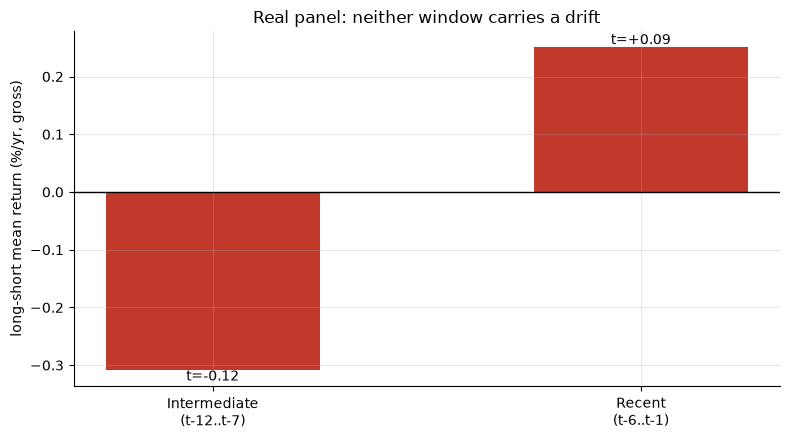

Intermediate: -0.31%/yr (t=-0.12)
Recent:       +0.25%/yr (t=+0.09)


In [3]:
if HAVE_REAL:
    int_m, int_t = s_int['mean']*100, s_int['tstat']
    rec_m, rec_t = s_rec['mean']*100, s_rec['tstat']
else:
    int_m, int_t = R['int_mean'], R['int_t']
    rec_m, rec_t = R['rec_mean'], R['rec_t']

fig, ax = plt.subplots(figsize=(8.0, 4.5))
labels = ['Intermediate\n(t-12..t-7)', 'Recent\n(t-6..t-1)']
vals = [int_m, rec_m]
cols = [RED if abs(t) < 2 else GREEN for t in [int_t, rec_t]]
bars = ax.bar(labels, vals, color=cols, width=0.5)
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, [int_t, rec_t]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(),
            f't={t:+.2f}', ha='center',
            va='bottom' if b.get_height() >= 0 else 'top', fontsize=10)
ax.set_ylabel('long-short mean return (%/yr, gross)')
ax.set_title('Real panel: neither window carries a drift')
plt.tight_layout(); plt.show()
print(f'Intermediate: {int_m:+.2f}%/yr (t={int_t:+.2f})')
print(f'Recent:       {rec_m:+.2f}%/yr (t={rec_t:+.2f})')

On the real basket the intermediate long-short earns **-0.31%/yr** (HAC *t* = **-0.12**) and the recent one **+0.25%/yr** (*t* = **+0.09**) -- both indistinguishable from zero, and the intermediate sort is marginally the **worse** of the two. Novy-Marx's ordering does not reproduce here.

## 5 -- The verdict

- **Signal -- NONE.** Intermediate *t* = -0.12, recent *t* = +0.09; both inside their placebo distributions (p = 0.56 / 0.40). Neither clears |t| >= 2.
- **Tradability -- MIRAGE.** Net of costs+borrow, both go negative (-1.50% / -0.94%/yr).
- **Intermediate wins? -- BUSTED (here).** The intermediate sort does not beat the recent one; the horizon decomposition dissolves on a large-cap survivor basket.

## 6 -- Could you actually trade it?

Even setting the flat signal aside, the obstacles are familiar:

1. **Turnover.** Monthly rank changes drive ~29% one-sided turnover; costs alone push an already-flat sort negative.
2. **Short borrow.** The short leg (past losers) accrues borrow fees, and the deepest losers are the hardest to borrow.
3. **Survivorship.** The very names that would have made the short leg pay -- past losers that delisted -- are not in a survivor basket. The real-world short leg is harder and costlier than the backtest shows.

## 7 -- Going further

- **Broader universe.** Novy-Marx used the full CRSP cross-section; the echo is strongest in smaller names. A Russell 3000 pull (with delisted names) would be the fair test.
- **International.** Goyal & Wahal (2015) find the echo is largely a US phenomenon -- weak or absent abroad.
- **[Study 24 -- Stampede](../../24-stampede/)**: plain 12-1 momentum -- the parent effect this study decomposes.
- **[Study 237 -- Residual-Momentum](../../237-residual-momentum/)**: another attempt to find a cleaner momentum signal.

*Think the intermediate echo survives in a broad, delisting-complete universe net of costs? Fork this, expand the basket, add delisted names, and show t > 2 on the intermediate sort. That is the bar.*